In [28]:
#importing all the required packages
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

import tensorflow as tf
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [29]:
#Reading the data
data = pd.read_csv('olympic.csv')

data

,Unnamed: 0,Name,Sex,Age,Team,Games,Year,Season,Sport,Medal
0,0,A Dijiang,M,24.0,China,1992 Summer,1992,Summer,Basketball,0
1,1,A Lamusi,M,23.0,China,2012 Summer,2012,Summer,Judo,0
2,2,Gunnar Nielsen Aaby,M,24.0,Denmark,1920 Summer,1920,Summer,Football,0
3,3,Edgar Lindenau Aabye,M,34.0,Denmark/Sweden,1900 Summer,1900,Summer,Tug-Of-War,3
4,4,Christine Jacoba Aaftink,F,21.0,Netherlands,1988 Winter,1988,Winter,Speed Skating,0
...,...,...,...,...,...,...,...,...,...,...
275638,4522,ZURABIANI Zurab,Male,21.0,Georgia,2020 Summer,2020,Summer,Judo,0
275639,4523,ZURBRUGG Lindsey,Female,22.0,United States of America,2020 Summer,2020,Summer,Wheelchair Basketball,1
275640,4524,ZVINOWANDA Vimbai,Female,29.0,Zimbabwe,2020 Summer,2020,Summer,Athletics,0
275641,4525,ZWOUKHI Fathi,Male,34.0,Tunisia,2020 Summer,2020,Summer,Triathlon,0


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275643 entries, 0 to 275642
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  275643 non-null  int64  
 1   Name        275643 non-null  object 
 2   Sex         275643 non-null  object 
 3   Age         266169 non-null  float64
 4   Team        275643 non-null  object 
 5   Games       275643 non-null  object 
 6   Year        275643 non-null  int64  
 7   Season      275643 non-null  object 
 8   Sport       275643 non-null  object 
 9   Medal       275643 non-null  int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 21.0+ MB


In [31]:
#seeing group summary of season column
data['Season'].value_counts()

Season
Summer    227079
Winter     48564
Name: count, dtype: int64

In [32]:
#seeing group summary of medal column
data['Medal'].value_counts()

Medal
0    234239
3     13957
1     13833
2     13614
Name: count, dtype: int64

In [33]:
#seeing group summary of event column
data['Sport'].value_counts()

Sport
Athletics        39766
Gymnastics       26707
Swimming         23799
Shooting         11602
Cycling          10859
                 ...  
Racquets            12
Jeu De Paume        11
Roque                4
Basque Pelota        2
Aeronautics          1
Name: count, Length: 79, dtype: int64

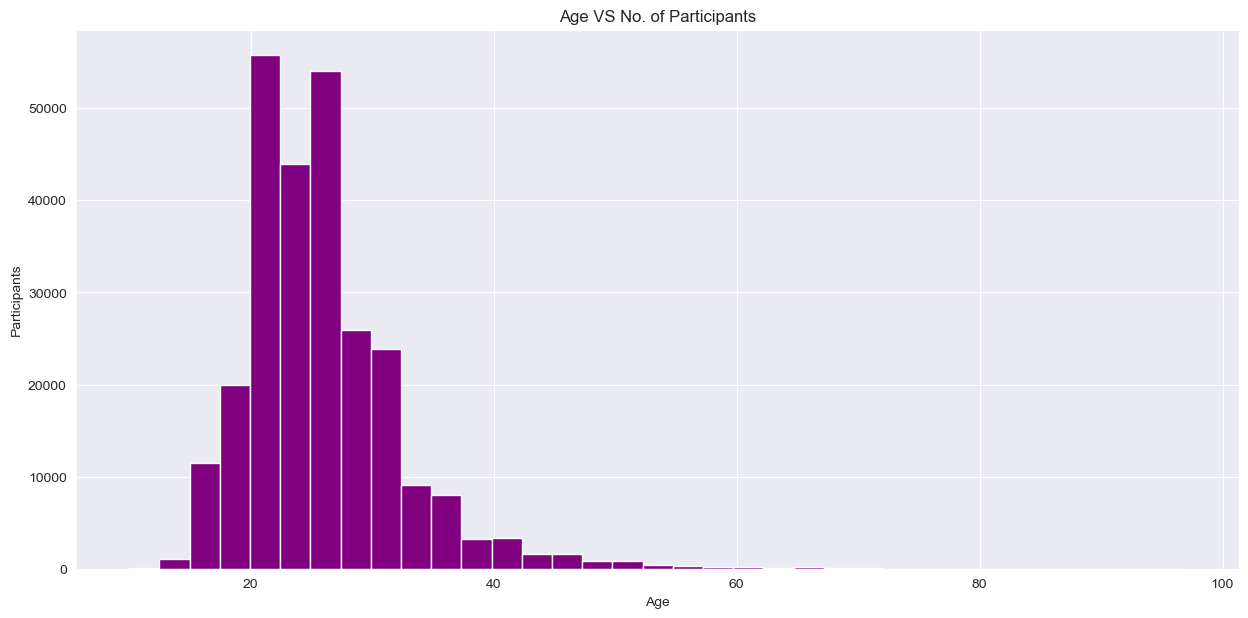

In [34]:
#Age Distribution
plt.figure(figsize=(15,7))
plt.title("Age VS No. of Participants")
plt.hist(data.Age,color='purple', bins = 35)
plt.xlabel("Age")
plt.ylabel("Participants")
plt.show()

In [35]:
#Age to participant distribution
age_dist = data.Age.value_counts().sort_values(ascending=False).head(15)
age_dist

Age
23.0    22053
24.0    21919
22.0    21013
25.0    19903
21.0    19312
26.0    17871
27.0    16224
20.0    15408
28.0    14229
19.0    11747
29.0    11665
30.0     9705
18.0     8212
31.0     7746
32.0     6441
Name: count, dtype: int64

In [36]:
#Gender Distribution
gender_unique_values = data.Sex.value_counts()
gender_unique_values

Sex
M         196594
F          74522
Male        2632
Female      1895
Name: count, dtype: int64

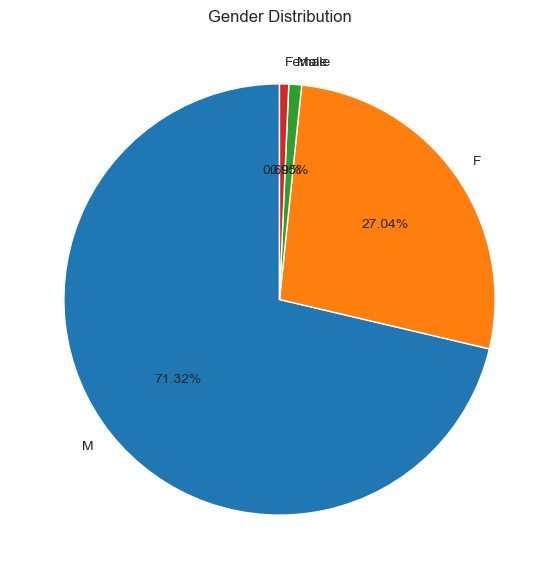

In [37]:
plt.figure(figsize=(15,7))
plt.title("Gender Distribution")
plt.pie(gender_unique_values, labels=gender_unique_values.index, autopct="%.2f%%", startangle=90)
plt.show()

In [38]:
#seeing female participants in each year in summer season

female_part = data[(data.Sex=='F') & (data.Season == 'Summer')][['Sex', 'Year']]
female_part = female_part.groupby('Year').count().reset_index()
female_part

,Year,Sex
0,1900,33
1,1904,16
2,1906,11
3,1908,47
4,1912,87
5,1920,134
6,1924,244
7,1928,404
8,1932,347
9,1936,468


Text(0, 0.5, 'Female Participants')

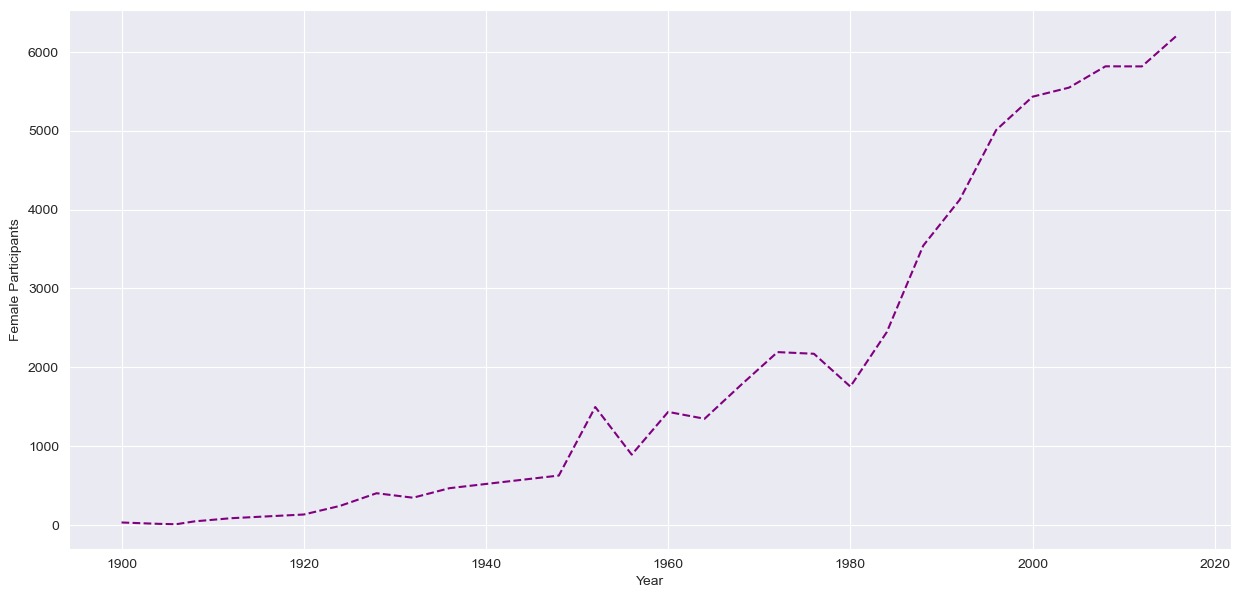

In [39]:
#Visualizing the female participant data

plt.figure(figsize=(15,7))
sns.lineplot(data=female_part, x='Year', y='Sex', linestyle = '--', color = 'purple')
plt.xlabel('Year')
plt.ylabel('Female Participants')

In [40]:
#Participants across the season

seasons = data.Season.value_counts()
seasons


Season
Summer    227079
Winter     48564
Name: count, dtype: int64

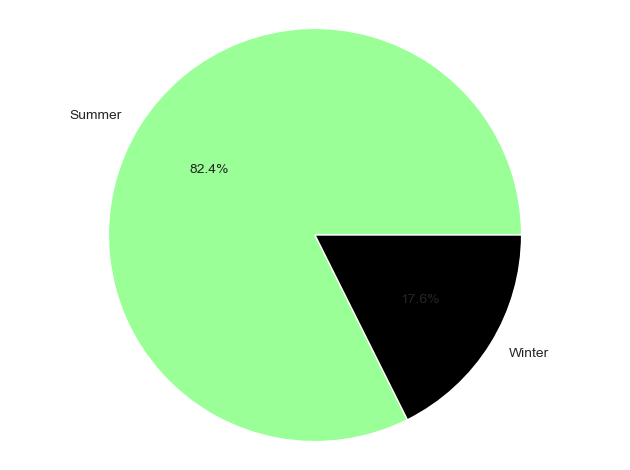

In [41]:
#visualizing partipant distribution in different season
fig1, ax1 = plt.subplots()

colors = ['#99ff96', '#000000']

ax1.pie(seasons, colors = colors, labels=seasons.index, autopct='%1.1f%%')
fig = plt.gcf()


ax1.axis('equal')
plt.tight_layout()
plt.show()

In [42]:
#Top 15 countries participating in olympics by no. of participants
top_countries = data.Team.value_counts().sort_values(ascending=False).head(15)
top_countries

Team
United States    17847
France           12134
Great Britain    11625
Italy            10374
Germany           9463
Canada            9408
Japan             8551
Sweden            8081
Australia         7694
Hungary           6586
Poland            6234
Switzerland       5865
Netherlands       5792
Soviet Union      5535
Finland           5395
Name: count, dtype: int64

<Axes: title={'center': 'Top 15 Countries Total Participations'}, xlabel='Team', ylabel='count'>

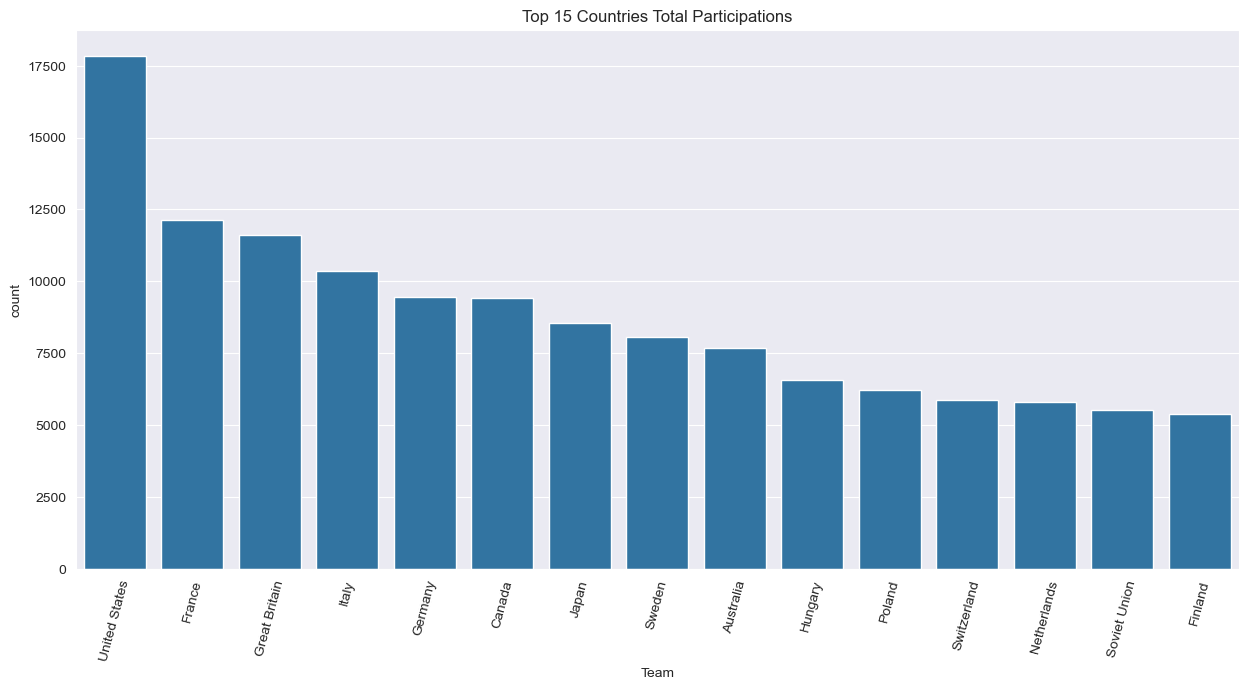

In [43]:
#Data visualization of countries participating
sns.set_style('darkgrid')
plt.figure(figsize=(15,7))
plt.title('Top 15 Countries Total Participations')
plt.xticks(rotation=75)
sns.barplot(x=top_countries.index, y=top_countries)

In [44]:
# Data of countries with most  medals

max_year_country = data[(data.Medal == 'Gold')].Team
max_year_country = max_year_country.value_counts().head(20)
max_year_country

Series([], Name: count, dtype: int64)

Text(0.5, 0, 'Top 20 Gold Medal Won Countrywise')

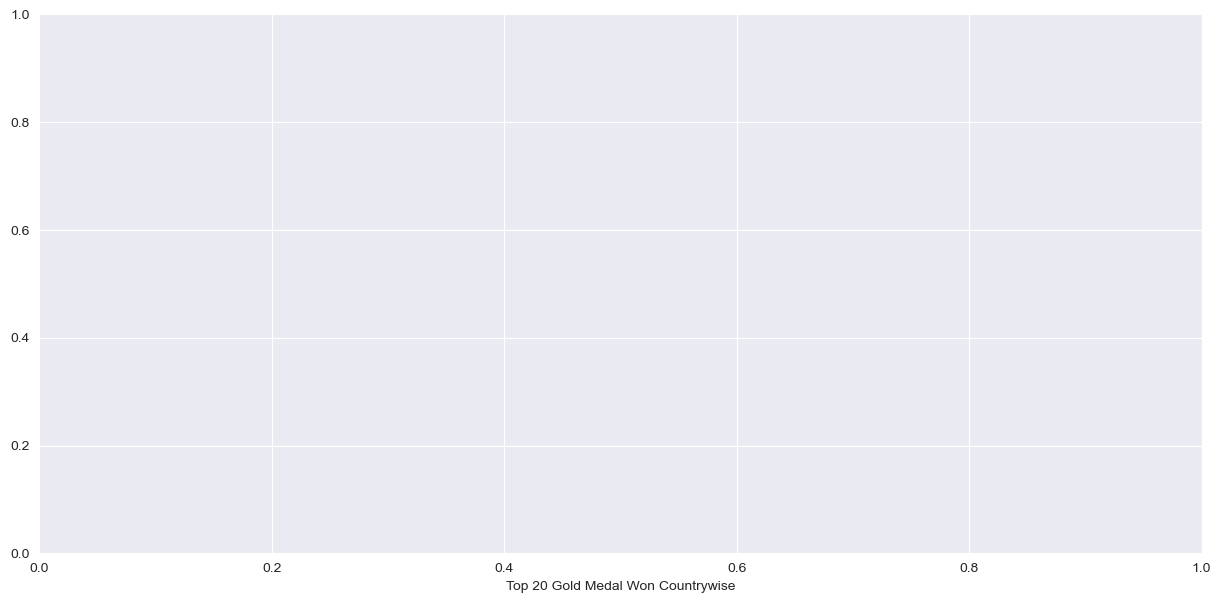

In [45]:
#visualizing the countries with most gold medals
plt.figure(figsize=(15,7))
sns.barplot(x=max_year_country, y=max_year_country.index)
plt.xlabel("Top 20 Gold Medal Won Countrywise")

In [46]:
#To fill missing values in Medal column with 0's and 1's
data['Medal'] = data['Medal'].apply(lambda x: 1 if str(x) != 'nan' else 0)

data

,Unnamed: 0,Name,Sex,Age,Team,Games,Year,Season,Sport,Medal
0,0,A Dijiang,M,24.0,China,1992 Summer,1992,Summer,Basketball,1
1,1,A Lamusi,M,23.0,China,2012 Summer,2012,Summer,Judo,1
2,2,Gunnar Nielsen Aaby,M,24.0,Denmark,1920 Summer,1920,Summer,Football,1
3,3,Edgar Lindenau Aabye,M,34.0,Denmark/Sweden,1900 Summer,1900,Summer,Tug-Of-War,1
4,4,Christine Jacoba Aaftink,F,21.0,Netherlands,1988 Winter,1988,Winter,Speed Skating,1
...,...,...,...,...,...,...,...,...,...,...
275638,4522,ZURABIANI Zurab,Male,21.0,Georgia,2020 Summer,2020,Summer,Judo,1
275639,4523,ZURBRUGG Lindsey,Female,22.0,United States of America,2020 Summer,2020,Summer,Wheelchair Basketball,1
275640,4524,ZVINOWANDA Vimbai,Female,29.0,Zimbabwe,2020 Summer,2020,Summer,Athletics,1
275641,4525,ZWOUKHI Fathi,Male,34.0,Tunisia,2020 Summer,2020,Summer,Triathlon,1


In [47]:
#Drop unnecessary feature columns
data = data.drop(['Name', 'Games'], axis=1)

#checking null values in the data
data.isna().mean()

Unnamed: 0    0.000000
Sex           0.000000
Age           0.034371
Team          0.000000
Year          0.000000
Season        0.000000
Sport         0.000000
Medal         0.000000
dtype: float64

In [48]:
#checking no. of unique values in the column
{column: len(data[column].unique()) for column in data.select_dtypes('object').columns}

{'Sex': 4, 'Team': 1203, 'Season': 2, 'Sport': 79}

In [60]:
import pandas as pd

# Load dataset
data = pd.read_csv("olympic.csv")

# Binary Encoding Function
def binary_encode(df, columns, positive_values):
    df = df.copy()
    for column, positive_value in zip(columns, positive_values):
        df[column] = df[column].apply(lambda x: 1 if x == positive_value else 0)
    return df

# One Hot Encoding Function
def onehot_encode(df, columns, prefixes):
    df = df.copy()
    for column, prefix in zip(columns, prefixes):
        dummies = pd.get_dummies(df[column], prefix=prefix)
        df = pd.concat([df, dummies], axis=1)
        df = df.drop(column, axis=1)
    return df

# Apply encoding
data = binary_encode(
    data,
    columns=['Sex', 'Season'],
    positive_values=['M', 'Summer']
)

data = onehot_encode(
    data,
    columns=['Team', 'Sport'],
    prefixes=['T', 'S']
)

# Display output
print(data.head())

   Unnamed: 0                      Name  Sex   Age        Games  Year  Season  \
0           0                 A Dijiang    1  24.0  1992 Summer  1992       1   
1           1                  A Lamusi    1  23.0  2012 Summer  2012       1   
2           2       Gunnar Nielsen Aaby    1  24.0  1920 Summer  1920       1   
3           3      Edgar Lindenau Aabye    1  34.0  1900 Summer  1900       1   
4           4  Christine Jacoba Aaftink    0  21.0  1988 Winter  1988       0   

   Medal  T_30. Februar  T_A North American Team  ...  S_Triathlon  \
0      0          False                    False  ...        False   
1      0          False                    False  ...        False   
2      0          False                    False  ...        False   
3      3          False                    False  ...        False   
4      0          False                    False  ...        False   

   S_Tug-Of-War  S_Volleyball  S_Water Polo  S_Weightlifting  \
0         False         Fals

In [61]:
#split data in target column and features columns
y = data['Medal']
x = data.drop('Medal', axis=1)

In [62]:
data = data[['Age', 'Sex', 'Year', 'Season',
         'T_Afghanistan', 'T_Algeria',
         'T_Angola', 'T_Argentina',
         'Medal']]

data.head()

,Age,Sex,Year,Season,T_Afghanistan,T_Algeria,T_Angola,T_Argentina,Medal
0,24.0,1,1992,1,False,False,False,False,0
1,23.0,1,2012,1,False,False,False,False,0
2,24.0,1,1920,1,False,False,False,False,0
3,34.0,1,1900,1,False,False,False,False,3
4,21.0,0,1988,0,False,False,False,False,0


In [63]:
y = data['Medal']
x = data.drop(['Medal'], axis=1)

In [76]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Remove missing values
data = data.dropna()

# Convert all object/string columns into numbers
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].astype('category').cat.codes

# Features and target
X = data.drop('Medal', axis=1)
y = data['Medal']

# Convert target into numeric
y = y.astype('category').cat.codes

# Split data
train_x, test_x, train_y, test_y = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1
)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)

# Train model
lr.fit(train_x, train_y)

# Prediction
lr_predict = lr.predict(test_x)

# Results
print("Confusion Matrix")
print(confusion_matrix(test_y, lr_predict))

print("\nAccuracy Score")
print(accuracy_score(test_y, lr_predict) * 100)

print("\nClassification Report")
print(classification_report(test_y, lr_predict))

Confusion Matrix
[[45174     0     0     0]
 [ 2687     0     0     0]
 [ 2601     0     0     0]
 [ 2772     0     0     0]]

Accuracy Score
84.85930044708269

Classification Report
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     45174
           1       0.00      0.00      0.00      2687
           2       0.00      0.00      0.00      2601
           3       0.00      0.00      0.00      2772

    accuracy                           0.85     53234
   macro avg       0.21      0.25      0.23     53234
weighted avg       0.72      0.85      0.78     53234



C:\Users\Public\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Public\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Public\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: Un

In [64]:
#split data into training and testing data
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.4, random_state=1)

In [69]:
#scaling data
scaler = MinMaxScaler()
train_x = scaler.fit_transform(train_x)
test_x = scaler.transform(test_x)

In [70]:
#Participants across the season

seasons = data.Sex.value_counts()
seasons


Sex
1    196594
0     79049
Name: count, dtype: int64

In [77]:
#2. multinomial naive bayes

algo2 = 'MultinomialNB'
nv = MultinomialNB()
nv.fit(train_x, train_y)
nv_predict = nv.predict(test_x)
nv_conf_matrix = confusion_matrix(test_y, nv_predict)
nv_acc_score = accuracy_score(test_y, nv_predict)
print("confusion matrix")
print(nv_conf_matrix)
print("\n")
print("Accuracy of Logistic Regression:",nv_acc_score*100,'\n')
print(classification_report(test_y,nv_predict))

confusion matrix
[[45174     0     0     0]
 [ 2687     0     0     0]
 [ 2601     0     0     0]
 [ 2772     0     0     0]]


Accuracy of Logistic Regression: 84.85930044708269 

              precision    recall  f1-score   support

           0       0.85      1.00      0.92     45174
           1       0.00      0.00      0.00      2687
           2       0.00      0.00      0.00      2601
           3       0.00      0.00      0.00      2772

    accuracy                           0.85     53234
   macro avg       0.21      0.25      0.23     53234
weighted avg       0.72      0.85      0.78     53234



C:\Users\Public\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Public\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Public\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [78]:
# 3. Decision Tree

algo3 = 'DecisionTreeClassifier'
dt = DecisionTreeClassifier(criterion = 'entropy',random_state=10,max_depth = 30)
dt.fit(train_x,train_y)
dt_predicted = dt.predict(test_x)
dt_conf_matrix = confusion_matrix(test_y, dt_predicted)
dt_acc_score = accuracy_score(test_y, dt_predicted)
print("confusion matrix")
print(dt_conf_matrix)
print("\n")
print("Accuracy of DecisionTreeClassifier:",dt_acc_score*100,'\n')
print(classification_report(test_y,dt_predicted))

confusion matrix
[[45115    10    25    24]
 [ 2674     5     2     6]
 [ 2590     3     3     5]
 [ 2757     1     7     7]]


Accuracy of DecisionTreeClassifier: 84.77664650411391 

              precision    recall  f1-score   support

           0       0.85      1.00      0.92     45174
           1       0.26      0.00      0.00      2687
           2       0.08      0.00      0.00      2601
           3       0.17      0.00      0.00      2772

    accuracy                           0.85     53234
   macro avg       0.34      0.25      0.23     53234
weighted avg       0.75      0.85      0.78     53234



In [79]:
# 4. Random Forest

algo4 = 'Random Forest Classfier'
rf = RandomForestClassifier(n_estimators=200, random_state=10,max_depth=15)
rf.fit(train_x,train_y)
rf_predicted = rf.predict(test_x)
rf_conf_matrix = confusion_matrix(test_y, rf_predicted)
rf_acc_score = accuracy_score(test_y, rf_predicted)
print("confusion matrix")
print(rf_conf_matrix)
print("\n")
print("Accuracy of Random Forest:",rf_acc_score*100,'\n')
print(classification_report(test_y,rf_predicted))

confusion matrix
[[45136     3    16    19]
 [ 2680     2     0     5]
 [ 2593     0     2     6]
 [ 2759     1     3     9]]


Accuracy of Random Forest: 84.8123379794868 

              precision    recall  f1-score   support

           0       0.85      1.00      0.92     45174
           1       0.33      0.00      0.00      2687
           2       0.10      0.00      0.00      2601
           3       0.23      0.00      0.01      2772

    accuracy                           0.85     53234
   macro avg       0.38      0.25      0.23     53234
weighted avg       0.75      0.85      0.78     53234



In [80]:
# 5. Gradient Boosting

algo5 = 'Gradient Boosting Classifier'
gvc =  GradientBoostingClassifier()
gvc.fit(train_x,train_y)
gvc_predicted = gvc.predict(test_x)
gvc_conf_matrix = confusion_matrix(test_y, gvc_predicted)
gvc_acc_score = accuracy_score(test_y, gvc_predicted)
print("confusion matrix")
print(gvc_conf_matrix)
print("\n")
print("Accuracy of Gradient Boosting Classifier:",gvc_acc_score*100,'\n')
print(classification_report(test_y,gvc_predicted))

confusion matrix
[[45170     0     4     0]
 [ 2684     0     1     2]
 [ 2599     0     1     1]
 [ 2772     0     0     0]]


Accuracy of Gradient Boosting Classifier: 84.85366495097118 

              precision    recall  f1-score   support

           0       0.85      1.00      0.92     45174
           1       0.00      0.00      0.00      2687
           2       0.17      0.00      0.00      2601
           3       0.00      0.00      0.00      2772

    accuracy                           0.85     53234
   macro avg       0.25      0.25      0.23     53234
weighted avg       0.73      0.85      0.78     53234



C:\Users\Public\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Public\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Public\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [82]:
# 6. Neural Network

import tensorflow as tf

algo6 = 'Neural Network'

# Input Layer
inputs = tf.keras.Input(shape=(X.shape[1],))

# Hidden Layers
x = tf.keras.layers.Dense(64, activation='relu')(inputs)
x = tf.keras.layers.Dense(64, activation='relu')(x)

# Output Layer
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

# Model
model = tf.keras.Model(inputs, outputs)

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

# Train Model
history = model.fit(
    train_x,
    train_y,
    validation_split=0.4,
    batch_size=32,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/100
3993/3993 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.6070 - auc: 0.4988 - loss: 2.2474 - val_accuracy: 0.8474 - val_auc: 0.5617 - val_loss: 1.1120
Epoch 2/100
3993/3993 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.6278 - auc: 0.5039 - loss: 1.1688 - val_accuracy: 0.8474 - val_auc: 0.5658 - val_loss: 0.9388
Epoch 3/100
3993/3993 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.6479 - auc: 0.5051 - loss: 0.9289 - val_accuracy: 0.8474 - val_auc: 0.5675 - val_loss: 0.6715
Epoch 4/100
3993/3993 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.6949 - auc: 0.5050 - loss: 0.7548 - val_accuracy: 0.8474 - val_auc: 0.5646 - val_loss: 0.6108
Epoch 5/100
3993/3993 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.7475 - auc: 0.5075 - loss: 0.6846 - val_accuracy: 0.8474 - val_auc: 0.5647 - val_loss: 0.6172
Epoch 6/100
3993/3993 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8216 - auc: 0.5060 - loss: 0.6382 - val_accuracy: 0.8474 - val_auc: 0.5655 - val_loss: 0.6166
Epoch 7/100
3993